In [1]:
import matplotlib.pyplot as plt
import numpy as np

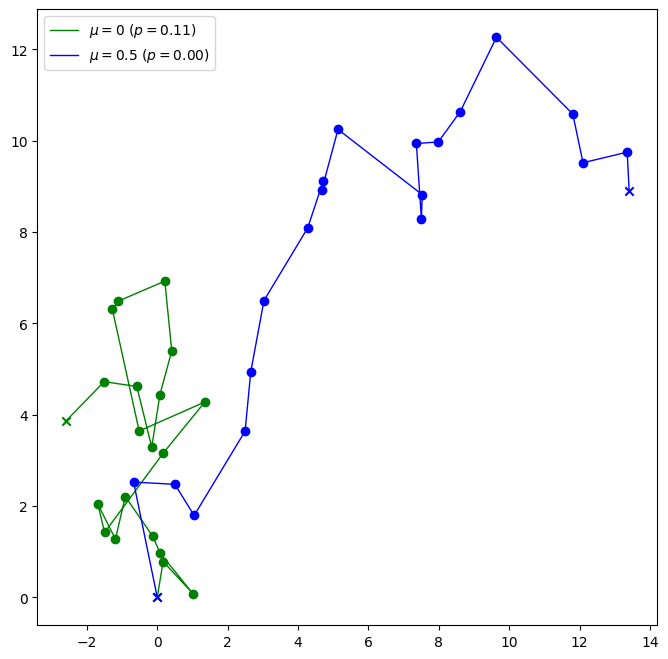

In [18]:
fig, ax = plt.subplots(1,1, figsize=(8,8))

n, dim = 20, 2
drifts = [0, 0.5]
n_permutations = 1000
seed = 314
mus = [np.ones(dim) * drift for drift in drifts]
colors = ["g", "b"]

np.random.seed(seed)

for i, mu in enumerate(mus):
    
    # --- CONSTRUCT RANDOM WALK ---
    d = []
    steps = np.random.multivariate_normal(mu, np.eye(dim), size=n)
    walk = np.cumsum(steps, axis=0)
    d.append([0,0])
    d.append(walk)
    d = np.vstack(d)

    # --- COMPUTE RW LL ---
    muhat = np.mean(steps, axis=0)
    cov = np.cov(steps, rowvar=False, ddof=1)
    pinv = np.linalg.pinv(cov)
    obs_lam = 0.5 * (n - 1) * (muhat.T @ pinv @ muhat)

    # --- COMPUTE P VALUE ---
    all_lams = []
    for _ in range(n_permutations):
        d_copy = d.copy()
        np.random.shuffle(d_copy)
        steps_shuffled = d_copy[1:,:] - d_copy[:-1,:]
        muhat_shuffled = np.mean(steps_shuffled, axis=0)
        lam_shuffled = 0.5 * (n - 1) * (muhat_shuffled.T @ pinv @ muhat_shuffled)
        all_lams.append(lam_shuffled)

    pve = np.mean(np.array(all_lams) > obs_lam)

    c = colors[i]
    ax.plot(
        d[:,0], d[:,1], 
        color=c, linestyle="-", linewidth=1, 
        label=f"$\\mu=${drifts[i]} ($p=${pve:.2f})"
    )
    ax.scatter(d[1:-1,0], d[1:-1,1], c=c)
    ax.scatter(d[[0,-1],0], d[[0,-1],1], c=c, marker="x")

ax.legend()
plt.show()

In [17]:
d

array([[ 2.11496127, -2.59646052],
       [ 4.03027459, -2.41068036],
       [ 5.25551206, -0.38632881],
       [ 4.63235179,  0.2533516 ],
       [ 5.45031808,  1.95422146],
       [ 7.4372966 ,  2.87389113],
       [ 9.18204437,  1.96319847],
       [ 9.56161002,  2.81685922],
       [10.32634272,  3.92310904],
       [10.3548007 ,  4.45630502],
       [10.83414721,  5.11652082],
       [12.20202005,  6.67739914],
       [14.20543299,  7.36276348],
       [13.03770528,  6.6407582 ],
       [12.84277351,  8.1864185 ],
       [13.57341403,  9.79614472],
       [15.76976738,  8.66946564],
       [15.63911349,  8.62904445],
       [14.29123141,  7.92777714],
       [13.75622523, 10.64690895]])